# Real Estate Pricing Intelligence

--- 

## 🏢 Contexto: a empresa Cascade Urban Analytics

A Cascade Urban Analytics é uma empresa de inteligência imobiliária que atua na região de King County (Seattle). Ela fornece:

valuation de imóveis
insights para incorporadoras
recomendação de investimento para fundos imobiliários
suporte a plataformas de compra/venda

**📉 Problema de fundo**

Nos últimos 18 meses, o mercado ficou mais volátil:

- Preços variando muito entre regiões próximas
- Clientes institucionais exigindo previsões mais confiáveis
- Concorrentes usando modelos mais sofisticados
- A empresa percebeu que seu modelo atual não está capturando a complexidade espacial e estrutural dos preços.

---

<p align="left">
  <img src="imagens/cascade_price_intelligence_cover.png" width="800">
</p>

---

## 🧩 Problemas de negócio 

🔴 Problema 1 — Valuation inconsistente

Situação

**Clientes reclamam que:**

- Imóveis semelhantes recebem preços muito diferentes
- Avaliações não refletem localização corretamente
- Erros altos em imóveis premium

**Impacto:**

- Perda de confiança
- Churn de clientes institucionais
- Decisões ruins de investimento

**Pergunta de negócio**

“Como podemos prever o preço de um imóvel com alta precisão considerando localização, características e qualidade?”

---

---

🔵 Problema 2 — **Identificação de oportunidades de investimento**

**Situação**

Fundos parceiros querem saber:

- Onde comprar imóveis subvalorizados    
- Quais regiões têm maior potencial de valorização
    

Hoje a empresa não consegue responder isso de forma quantitativa.

**Impacto**

- Perda de contratos com fundos imobiliários    
- Decisões baseadas em intuição (alto risco)
    

**Pergunta de negócio**

> “Quais imóveis estão sendo vendidos abaixo do valor esperado?”

---

---

🟢 Problema 3 — **Compreensão dos drivers de preço**

**Situação**

**Executivos e clientes perguntam:**

- O que realmente impacta o preço?    
- Vale mais investir em reforma ou localização?
- Quantos banheiros realmente agregam valor?
    

E hoje a empresa não tem respostas claras.

**Impacto**

- Dificuldade em justificar decisões
- Perda de credibilidade analítica
    

**Pergunta de negócio**

> Quais variáveis mais influenciam o preço e como?

---

# 1.0 Instalando e Carregando Pacotes

In [1]:
import importlib    # Importa o módulo 'importlib', que permite importar bibliotecas dinamicamente em tempo de execução
import subprocess   # Importa o módulo 'subprocess' para executar comandos externos, como instalar pacotes via pip
import sys          # Importa o módulo 'sys' para acessar o interpretador Python atual e seu executável


# Dicionário contendo os pacotes que devem ser verificados e instalados, se necessário.
# Estrutura: {nome_import: nome_instalacao_pip}
required_packages = {
    'sklearn': 'scikit-learn',     # Alias crítico: módulo é 'sklearn', mas distribuição no pip é 'scikit-learn'
    'scipy': 'scipy',              # Nome consistente entre importação e instalação
    'pandas': 'pandas',            # DataFrames e manipulação de dados estruturados
    'numpy': 'numpy',              # Base para computação numérica vetorizada
    'matplotlib': 'matplotlib',    # Biblioteca base para visualização (baixo nível)
    'seaborn': 'seaborn',          # Abstração estatística sobre matplotlib
    'missingno': 'missingno',      # Visualização de padrões de dados ausentes (EDA)
    'plotly': 'plotly',            # Visualização interativa (frontend-ready)
    'statsmodels': 'statsmodels',  # Modelagem estatística (inferência, regressões)
    'statstests': 'statstests',    # Testes estatísticos adicionais (menos comum, cuidado com compatibilidade)
    'missingno': 'missingno',      # Biblioteca para visualização de dados ausentes 
    'datetime': 'datetime'         # Módulo datetime para trabalhar com datas e horários
}
# Função responsável por verificar se o pacote está disponível no ambiente Python
def check_and_install(package_name, install_name):
    try:
        importlib.import_module(package_name)  # Tentativa dinâmica de importação (evita import estático)
        print(f"✅ Biblioteca '{package_name}' já está instalada.")  # Feedback positivo para logging
    except ImportError:  # Captura falha de importação → pacote ausente no ambiente
        print(f"⚠️ Biblioteca '{package_name}' não encontrada. Instalando '{install_name}'...")
        
        # Executa comando de instalação via subprocess:
        # sys.executable garante uso do mesmo interpretador Python ativo (evita conflitos de ambiente)
        # "-m pip install" é mais seguro que chamar pip diretamente (compatibilidade cross-env)
        subprocess.check_call([
            sys.executable,        # Caminho do Python atual
            "-m", "pip",           # Execução do módulo pip
            "install", install_name  # Nome do pacote no repositório PyPI
        ])
        
        print(f"✅ Biblioteca '{install_name}' instalada com sucesso.")  # Confirmação pós-instalação

# Iteração sobre o dicionário de dependências
for package, install_name in required_packages.items():
    check_and_install(package, install_name)  # Execução sequencial (sem paralelismo)

✅ Biblioteca 'sklearn' já está instalada.
✅ Biblioteca 'scipy' já está instalada.
✅ Biblioteca 'pandas' já está instalada.
✅ Biblioteca 'numpy' já está instalada.
✅ Biblioteca 'matplotlib' já está instalada.
✅ Biblioteca 'seaborn' já está instalada.
✅ Biblioteca 'missingno' já está instalada.
✅ Biblioteca 'plotly' já está instalada.
✅ Biblioteca 'statsmodels' já está instalada.
✅ Biblioteca 'statstests' já está instalada.
✅ Biblioteca 'datetime' já está instalada.


In [2]:
import pandas as pd                                 # manipulação de dados em formato de dataframe
import numpy as np                                  # operações matemáticas
import seaborn as sns                               # visualização gráfica
import matplotlib.pyplot as plt                     # visualização gráfica
import plotly.graph_objects as go                   # gráficos 3D
from scipy.stats import pearsonr                    # correlações de Pearson
import statsmodels.api as sm                        # estimação de modelos
from statsmodels.iolib.summary2 import summary_col  # comparação entre modelos
from sklearn.preprocessing import LabelEncoder      # transformação de dados
from statstests.process import stepwise             # procedimento Stepwise
from statstests.tests import shapiro_francia        # teste de Shapiro-Francia
from scipy.stats import boxcox                      # transformação de Box-Cox
from scipy.stats import norm                        # para plotagem da curva normal
from scipy import stats                             # utilizado na definição da função 'breusch_pagan_test'
import missingno as msno                            # Biblioteca para visualização de dados ausentes
from sklearn.linear_model import LinearRegression   # Modelo de Regressão 
from sklearn.model_selection import train_test_split
from datetime import datetime # Importa o módulo datetime para trabalhar com datas e horários



In [3]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Ricardo de Souza Silva" 

Author: Ricardo de Souza Silva



# 2.0 Carregando os Dados

In [9]:
# Lista para identificar os valores ausentes
lista_labels_valores_ausentes = ["n/a,", "na", "undefined"]

In [10]:
dataset = pd.read_csv('data/house_prices.csv', na_values= lista_labels_valores_ausentes)

In [11]:
dataset.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [12]:
dataset.shape

(21613, 21)

In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# 3.0 Limpeza e Pré-Processamento

## 3.1 Renomeação e Adequação das Colunas (Variáveis)

---

Visando aprimorar a legibilidade e a interpretabilidade do dataset, foi realizada a padronização da nomenclatura das variáveis do inglês para o português.

Essa decisão busca facilitar o entendimento semântico dos atributos e tornar a análise mais acessível para usuários de língua portuguesa. 

---

In [14]:
renomeando = {
    "price": "preco_venda",                 # variável alvo (target)
    "bedrooms": "num_quartos",              # variável de contagem
    "bathrooms": "num_banheiros",           # pode conter valores fracionados (ex: 1.5)
    "sqft_living": "area_util_pes2",        # área interna habitável (principal feature preditiva)
    "sqft_lot": "area_terreno_pes2",        # área total do terreno
    "floors": "num_andares",                # número de níveis da casa
    "waterfront": "possui_vista_agua",      # variável binária (0 = não, 1 = sim)
    "view": "pontuacao_vista",              # variável ordinal (0 a 4)
    "condition": "pontuacao_condicao",      # estado geral do imóvel (1 a 5)
    "grade": "classificacao_construcao",    # qualidade da construção/design (1 a 13)
    "sqft_above": "area_acima_solo_pes2",   # área acima do nível do solo
    "sqft_basement": "area_porao_pes2",     # área do porão
    "yr_built": "ano_construcao",           # ano de construção
    "yr_renovated": "ano_reforma",          # 0 indica que nunca foi reformado (atenção para feature engineering)
    "zipcode": "codigo_postal",             # variável categórica (não tratar como numérica em modelos)
    "sqft_living15": "area_media_vizinhos_pes2",        # média da área útil das casas vizinhas (contexto regional)
    "sqft_lot15": "area_terreno_media_vizinhos_pes2"    # média da área de terreno da vizinhança
}
# aplica a renomeação das colunas no dataset
dataset = dataset.rename(columns=renomeando)

In [15]:
dataset.drop(labels=['id', 'date', 'lat', 'long'], axis=1, inplace=True)

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco_venda                       21613 non-null  float64
 1   num_quartos                       21613 non-null  int64  
 2   num_banheiros                     21613 non-null  float64
 3   area_util_pes2                    21613 non-null  int64  
 4   area_terreno_pes2                 21613 non-null  int64  
 5   num_andares                       21613 non-null  float64
 6   possui_vista_agua                 21613 non-null  int64  
 7   pontuacao_vista                   21613 non-null  int64  
 8   pontuacao_condicao                21613 non-null  int64  
 9   classificacao_construcao          21613 non-null  int64  
 10  area_acima_solo_pes2              21613 non-null  int64  
 11  area_porao_pes2                   21613 non-null  int64  
 12  ano_

In [17]:
dataset.sample(10)

,preco_venda,num_quartos,num_banheiros,area_util_pes2,area_terreno_pes2,num_andares,possui_vista_agua,pontuacao_vista,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,ano_construcao,ano_reforma,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2
20614,308625.0,2,2.00,1500,1408,3.0,0,0,3,7,1500,0,1999,0,98133,1500,1245
5255,658000.0,3,1.00,1290,12005,1.0,0,0,4,7,1290,0,1966,0,98033,1930,8000
19320,746000.0,3,1.75,1910,12321,1.0,0,0,4,7,1100,810,1952,0,98004,1910,11761
11710,219950.0,3,1.50,1200,8404,1.0,0,0,3,7,1200,0,1964,0,98188,2120,12000
16920,420000.0,3,1.00,1310,3963,1.0,0,0,5,7,1310,0,1986,0,98052,1010,3363
20825,369946.0,3,2.50,2420,4725,2.0,0,0,3,8,2420,0,2014,0,98038,2370,4200
19105,463000.0,3,1.00,1250,7700,1.0,0,0,4,7,1250,0,1955,0,98007,1520,7700
5370,572650.0,4,2.50,2250,11349,2.0,0,0,3,8,2250,0,1991,0,98034,2110,9964
10452,655000.0,3,2.00,1820,4480,1.0,0,0,5,7,1120,700,1923,0,98105,1920,4480
6921,284000.0,2,1.00,860,7204,1.0,0,0,3,7,860,0,1918,0,98106,1200,7500


## 3.2 Verificação Valores Ausentes

---

Aqui utilizei a função `msno.matrix(dataset)` que tem como objetivo visualizar a distribuição dos valores ausentes no conjunto de dados de forma estruturada e intuitiva. Essa visualização permite identificar rapidamente a presença de dados faltantes, sua concentração em determinadas variáveis e possíveis padrões de ausência ao longo das observações.

Ao analisar a matriz, é possível verificar se os valores ausentes ocorrem de maneira aleatória ou se seguem algum padrão específico, o que é fundamental para orientar a estratégia de tratamento dos dados. Além disso, a visualização auxilia na identificação de colunas com alta proporção de valores nulos, que podem comprometer a qualidade da análise ou do modelo.

Em síntese, uma abordagem como essa contribui para uma avaliação mais robusta da qualidade dos dados, sendo uma etapa essencial no processo de preparação e análise de dados.


---

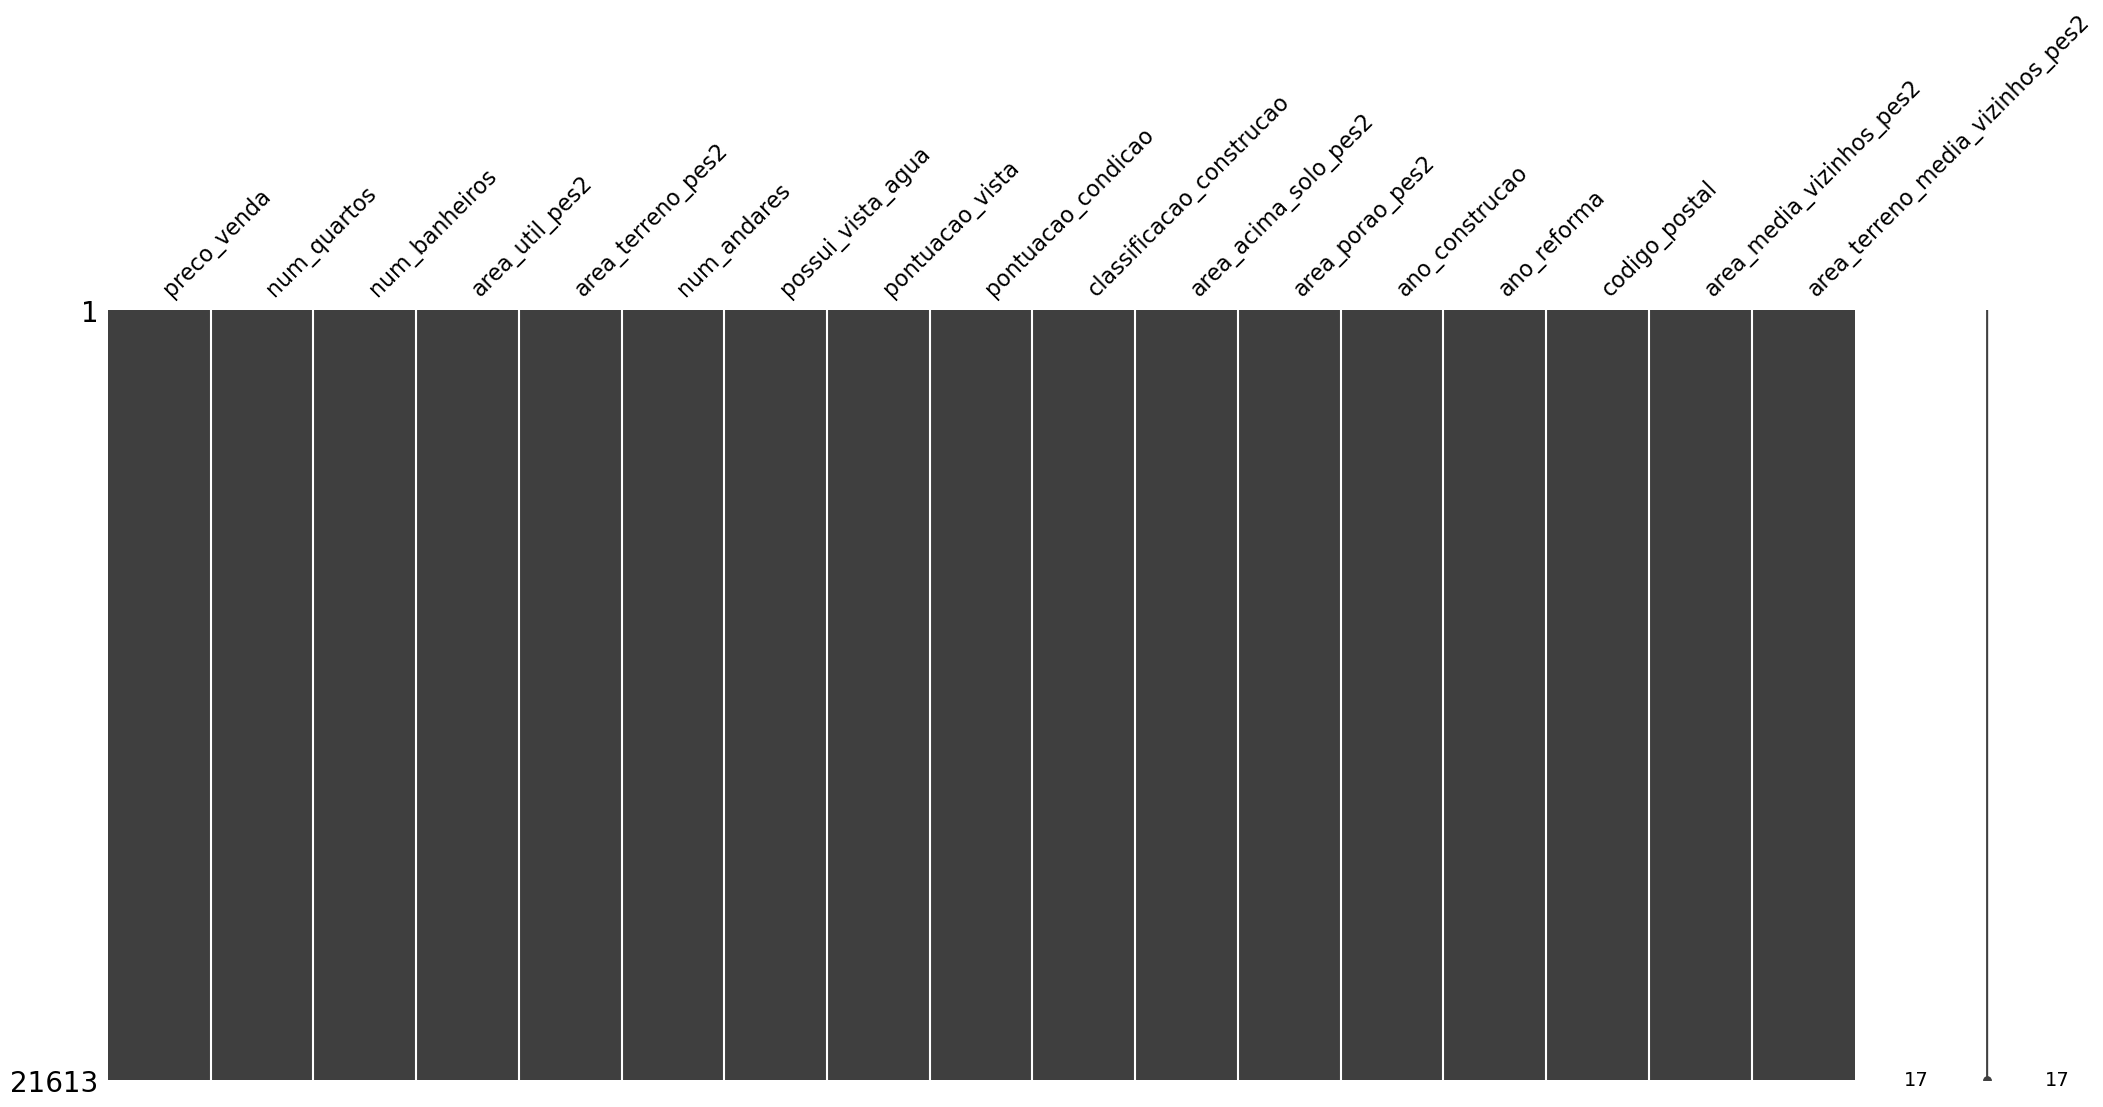

In [18]:
# Matriz de valores ausentes
msno.matrix(dataset)     # Gera uma visualização da matriz de dados ausentes do DataFrame 'dataset'
plt.show()               # Exibe a visualização gerada

## 3.3 Engenharia de Atributos

### 3.3.1 Tratando as Variáveis Temporais (ano_construcao, ano_reforma )

In [19]:
dataset.sample(5)

,preco_venda,num_quartos,num_banheiros,area_util_pes2,area_terreno_pes2,num_andares,possui_vista_agua,pontuacao_vista,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,ano_construcao,ano_reforma,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2
14596,685000.0,4,2.75,1660,5150,1.5,0,0,5,7,1280,380,1928,0,98117,1490,4017
161,438000.0,3,1.75,1780,9660,1.0,0,0,3,7,1780,0,1962,0,98034,1200,9660
14937,187000.0,2,1.75,1020,10346,1.0,0,0,4,6,1020,0,1983,0,98022,1160,8610
15466,453500.0,4,1.75,2000,6032,1.0,0,2,3,7,1300,700,1959,0,98146,1930,6032
5125,540000.0,3,2.25,2100,20018,1.0,0,4,3,8,1470,630,1948,0,98166,2410,17196


In [20]:
# Calcula a frequência de cada valor presente na coluna 'ano_construcao'
# (ou seja, quantas vezes cada ano de construção aparece no dataset)
dataset['ano_construcao'].value_counts().sort_index()
# Ordena o resultado pelo índice (anos) em ordem crescente,
# permitindo uma análise cronológica da distribuição dos dados

ano_construcao
1900     87
1901     29
1902     27
1903     46
1904     45
       ... 
2011    130
2012    170
2013    201
2014    559
2015     38
Name: count, Length: 116, dtype: int64

In [21]:
# Calcula a frequência de cada valor presente na coluna 'ano_reforma'
# (ou seja, quantas vezes cada ano de construção aparece no dataset)
dataset['ano_reforma'].value_counts().sort_index()
# Ordena o resultado pelo índice (anos) em ordem crescente,
# permitindo uma análise cronológica da distribuição dos dados

ano_reforma
0       20699
1934        1
1940        2
1944        1
1945        3
        ...  
2011       13
2012       11
2013       37
2014       91
2015       16
Name: count, Length: 70, dtype: int64

In [22]:
# Calcula e exibe o percentual de registros em que 'ano_reforma' é igual a 0
# A expressão (dataset['ano_reforma'] == 0) gera uma série booleana (True/False),
# o método .sum() contabiliza os True (equivalentes a 1),
# dividimos pelo total de registros (dataset.shape[0]) e multiplicamos por 100 para obter o percentual,
# e round(..., 2) arredonda o resultado para duas casas decimais
print(f'Percentual de dados com o valor zero em ano da reforma: {round((dataset["ano_reforma"] == 0).sum() / dataset.shape[0] * 100, 2)}')

# Calcula e exibe o percentual de registros em que 'ano_construcao' é igual a 0
# Segue a mesma lógica: contagem de valores iguais a zero sobre o total de registros,
# permitindo avaliar possíveis inconsistências ou ausência de informação nessa variável
print(f'Percentual de dados com o valor zero em ano da construção: {round((dataset["ano_construcao"] == 0).sum() / dataset.shape[0] * 100, 2)}')

Percentual de dados com o valor zero em ano da reforma: 95.77
Percentual de dados com o valor zero em ano da construção: 0.0


In [23]:
# Obtém o ano atual do sistema (ex: 2026), utilizado como referência temporal
# para o cálculo de variáveis derivadas relacionadas ao tempo
ano_atual = datetime.now().year

# Converte a coluna 'ano_construcao' para o tipo datetime
# O parâmetro format='%Y' indica que os valores representam apenas o ano (ex: 1995),
# garantindo consistência no tipo de dado e permitindo o uso do accessor .dt
dataset['ano_construcao'] = pd.to_datetime(dataset['ano_construcao'], format='%Y')

# Cria a variável derivada 'idade_imovel' a partir da diferença entre o ano atual
# e o ano de construção do imóvel
# A operação é vetorizada e utiliza .dt.year para extrair o ano da coluna datetime
# Essa variável tende a ser mais informativa para análise e modelagem do que o ano absoluto
dataset['idade_imovel'] = ano_atual - dataset['ano_construcao'].dt.year

# Remove as colunas 'ano_construcao' e 'ano_reforma' do dataset
# - 'ano_construcao' é descartada por redundância após a criação de 'idade_imovel'
# - 'ano_reforma' é removida devido à alta concentração de valores nulos ou iguais a zero,
#   o que reduz seu poder explicativo e pode introduzir ruído na análise/modelo
dataset.drop(labels=['ano_construcao', 'ano_reforma'], axis=1, inplace=True)

---

**Justificativa para remoção das variáveis**

A variável **`ano_construcao`** foi removida após a criação da variável derivada **`idade_imovel`** (ou *anos de construção*), calculada a partir da diferença entre o ano atual e o ano de construção. Essa transformação permite representar o tempo de forma mais diretamente interpretável e alinhada com o comportamento esperado em modelos preditivos, uma vez que a idade do imóvel tende a capturar melhor o efeito temporal do que o ano absoluto. Além disso, evita-se redundância e possível multicolinearidade entre variáveis altamente correlacionadas.

Já a variável **`ano_reforma`** foi removida devido à alta concentração de valores iguais a zero, indicando ausência de reforma na maior parte dos registros. Essa predominância reduz significativamente o poder informativo da variável, além de dificultar a extração de padrões relevantes. Dessa forma, sua manutenção poderia introduzir ruído no modelo sem contribuir de maneira efetiva para a capacidade explicativa.

---

### 3.3.2 Tratando a Variável (num_banheiros)

In [24]:
dataset.sample(5)

,preco_venda,num_quartos,num_banheiros,area_util_pes2,area_terreno_pes2,num_andares,possui_vista_agua,pontuacao_vista,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2,idade_imovel
12822,343000.0,2,1.00,1110,9920,1.0,0,0,5,6,700,410,98056,2830,10091,84
240,225000.0,3,1.75,1430,8505,1.0,0,0,4,7,1430,0,98003,1190,8640,58
3737,460000.0,2,1.00,1020,4002,1.0,0,0,5,7,1020,0,98116,1780,5000,73
2359,262000.0,4,2.50,2020,6236,2.0,0,0,3,7,2020,0,98001,1940,5076,24
6431,354500.0,3,1.00,1150,11396,1.5,0,0,4,7,1150,0,98155,1600,8146,76


In [25]:
dataset['num_banheiros'].value_counts().sort_index()

num_banheiros
0.00      10
0.50       4
0.75      72
1.00    3852
1.25       9
1.50    1446
1.75    3048
2.00    1930
2.25    2047
2.50    5380
2.75    1185
3.00     753
3.25     589
3.50     731
3.75     155
4.00     136
4.25      79
4.50     100
4.75      23
5.00      21
5.25      13
5.50      10
5.75       4
6.00       6
6.25       2
6.50       2
6.75       2
7.50       1
7.75       1
8.00       2
Name: count, dtype: int64

---

## 🧠 Justificativa para valores fracionados em `num_banheiros`

Pelo que verifiquei nesse dataset o número de banheiros não é tratado apenas como uma contagem inteira, mas sim como uma **medida ponderada da infraestrutura disponível no imóvel**.

Isso acontece porque nem todos os banheiros possuem o mesmo nível de funcionalidade. Um banheiro completo (com vaso sanitário, pia e chuveiro ou banheira) oferece mais utilidade e conforto do que um lavabo (apenas vaso e pia), por exemplo.

Dessa forma, ficasse entendido que esse dataset adota uma convenção onde:

* **banheiros completos** são contabilizados como `1.0`
* **lavabos (meio banheiro)** são contabilizados como `0.5`
* **instalações parciais adicionais** (como um espaço com chuveiro, mas sem todos os componentes) podem contribuir com valores intermediários como `0.25`

Como resultado, o total de banheiros passa a ser representado como uma variável contínua, podendo assumir valores como:

* `1.0` → um banheiro completo
* `1.5` → um banheiro completo + um lavabo
* `2.75` → dois banheiros completos + combinações parciais adicionais

---

## 🎯 Por que isso é importante para análise de dados

Essa representação permite capturar melhor o **nível real de conforto e funcionalidade do imóvel**, ao invés de simplesmente contar unidades físicas.

Do ponto de vista analítico:

* dois imóveis com “2 banheiros” podem ser muito diferentes se um deles tiver um lavabo adicional
* o impacto no preço não é uniforme entre componentes completos e parciais
* a variável carrega **informação de qualidade, não apenas quantidade**

---

## 📌 Conclusão

Portanto, os valores fracionados em `num_banheiros` não são erros ou inconsistências, mas sim uma forma padronizada de representar a composição dos banheiros de um imóvel de maneira mais precisa.

Essa abordagem torna a variável mais informativa e mais adequada para modelagem preditiva, pois reflete melhor a realidade do mercado imobiliário.

---



In [27]:
# cria variáveis derivadas a partir do número total de banheiros

# extrai a parte inteira → representa a quantidade de banheiros completos
# OBS: np.int está depreciado → usar int() ou np.floor para maior segurança
dataset["banheiro_completo"] = dataset["num_banheiros"].astype(int)

# calcula a parte fracionária → representa banheiros complementares (lavabos ou parciais)
dataset["banheiro_complementar"] = dataset["num_banheiros"] - dataset["banheiro_completo"]

# cria variável binária: 1 se existe qualquer banheiro complementar, 0 caso contrário
dataset["banheiro_complementar"] = (dataset["banheiro_complementar"] > 0).astype(int)

# remove a variável original de banheiros após decomposição
# justificativa:
# - a informação foi preservada e melhor representada nas variáveis derivadas
# - evita redundância e possível multicolinearidade no modelo
dataset.drop(labels=['num_banheiros'], axis=1, inplace=True)

In [28]:
dataset.sample(5)

,preco_venda,num_quartos,area_util_pes2,area_terreno_pes2,num_andares,possui_vista_agua,pontuacao_vista,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2,idade_imovel,banheiro_completo,banheiro_complementar
12681,252000.0,3,1420,6788,2.0,0,0,3,7,1420,0,98023,1790,6607,36,2,0
11365,317000.0,6,2120,5840,2.0,0,0,5,7,2120,0,98055,1860,8000,47,3,1
2519,545000.0,4,2090,6023,2.0,0,0,3,8,2090,0,98029,2090,6023,36,2,1
5025,1165000.0,4,3920,4500,3.0,0,0,3,8,3920,0,98103,2040,3000,13,3,1
8633,315000.0,2,860,8308,1.0,0,0,3,7,860,0,98146,1200,8308,78,1,0


---

### 🧠 Justificativa para criação de `banheiro_completo` e `banheiro_complementar`

A variável `num_banheiros` é representada de forma contínua porque agrega diferentes tipos de instalações sanitárias (banheiros completos e parciais) em uma única métrica.

No entanto, essa representação introduz um problema analítico relevante:

> componentes distintos são tratados como equivalentes, apesar de gerarem impactos diferentes no valor do imóvel.

Um banheiro completo possui maior valor funcional e econômico, enquanto instalações parciais (como lavabos) têm impacto marginal. Ao manter essa informação agregada, o modelo perde a capacidade de distinguir esses efeitos.

---

### 🎯 Decisão analítica

Para resolver essa limitação, optamos por decompor a variável original em duas dimensões:

* **`banheiro_completo`** → quantidade de banheiros completos (parte inteira)
* **`banheiro_complementar`** → indicador de presença de banheiro de apoio (0 ou 1)

> Neste caso, `banheiro_complementar` não representa quantidade, mas sim **presença de infraestrutura adicional**.

---

### 📊 Benefícios dessa abordagem

#### 1. Melhor alinhamento com a lógica do mercado

A decisão de compra não depende apenas da quantidade total de banheiros, mas da **existência de um banheiro adicional de apoio**.

👉 Exemplo:

* 2 banheiros vs 2 banheiros + lavabo → diferença real de valor percebido

---

#### 2. Captura de efeitos não lineares

A transformação permite ao modelo aprender:

* impacto estrutural → banheiros completos
* impacto incremental → presença de banheiro complementar

Sem precisar de técnicas mais complexas.

---

#### 3. Redução de ruído e simplificação

Ao binarizar `banheiro_complementar`, evitamos modelar variações pouco relevantes (0.25, 0.5, 0.75), que muitas vezes introduzem ruído sem ganho preditivo significativo.

---

#### 4. Maior interpretabilidade para negócio

Agora é possível responder de forma direta:

* “Quantos banheiros completos influenciam o preço?”
* “A presença de um banheiro de apoio agrega valor?”

👉 Isso facilita comunicação com stakeholders não técnicos.

---

### 🧩 Representação final

```text
banheiro_completo = parte inteira de num_banheiros
banheiro_complementar = 1, se existe fração > 0; caso contrário, 0
```

---

### 🧠 Interpretação prática

| num_banheiros | banheiro_completo | banheiro_complementar |
| ------------- | ----------------- | --------------------- |
| 2.0           | 2                 | 0                     |
| 2.5           | 2                 | 1                     |
| 2.75          | 2                 | 1                     |

---

### 📌 Conclusão

A decomposição da variável de banheiros transforma uma métrica agregada em uma representação mais aderente à realidade do mercado imobiliário.

Essa abordagem permite separar efeitos estruturais e incrementais, reduzindo ambiguidade, melhorando a interpretabilidade e aumentando o potencial preditivo do modelo — especialmente em cenários onde simplicidade e robustez são desejadas.

---
 


## 3.4 Verificação Valores Outliers

In [ ]:
# Cria boxplots individuais para cada coluna numérica do DataFrame 'dados_para_box_plot'
# Cada boxplot será exibido em um subplot separado
dataset.plot(
    subplots=True,          # Gera um gráfico separado (subplot) para cada variável
    layout=(4, 5),          # Organiza os subplots em um grid de 2 linhas e 7 colunas
    kind='box',             # Define o tipo de gráfico como boxplot
    figsize=(20, 15),        # Define o tamanho total da figura (largura=25, altura=8)
    patch_artist=True       # Preenche as caixas do boxplot com cores
)
# Ajusta o espaçamento horizontal entre os subplots
plt.subplots_adjust(wspace=0.5)

## 3.5 Tratamento de Outliers

In [ ]:
# Identificação de outliers através do método do IQR (Interquartile Range)
Q1 = dataset.quantile(0.25)  # Calcula o primeiro quartil (25º percentil) para cada coluna no DataFrame 'dataset'
Q3 = dataset.quantile(0.75)  # Calcula o terceiro quartil (75º percentil) para cada coluna no DataFrame 'dataset'
IQR = Q3 - Q1                # Calcula o intervalo interquartil (IQR) para cada coluna, subtraindo o primeiro quartil do terceiro quartil

In [ ]:
# Definir outliers como aqueles valores que estão fora do intervalo [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]
outliers = ((dataset < (Q1 - 1.5 * IQR)) | (dataset > (Q3 + 1.5 * IQR))).sum()  
# Identifica os outliers no DataFrame 'dataset' usando o intervalo interquartil (IQR).
# Considera valores abaixo de Q1 - 1.5 * IQR ou acima de Q3 + 1.5 * IQR como outliers.
# Conta o número de outliers em cada coluna e armazena o resultado na variável 'outliers'.    

In [ ]:
# Cria um resumo com os outliers
outliers_summary = pd.DataFrame({'Outliers': outliers,                                    # Cria uma coluna 'Outliers' com o número de outliers em cada coluna
                                  'Percentual': (outliers / len(dataset)) * 100})  # Cria uma coluna 'Percentual' com a porcentagem de outliers em relação ao total de linhas no DataFrame 'novo_dataframe'

# Retorna os resultados quando o valor for maior do que zero
# Filtra o DataFrame 'outliers_summary' para mostrar apenas as colunas que têm mais de 0 outliers
round(outliers_summary[outliers_summary['Outliers'] > 0])  